In [1]:
import os

from google.colab import userdata
token = userdata.get("KAGGLE_API_TOKEN")

!mkdir -p ~/.kaggle
!echo "{token}" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [2]:
from google.colab import userdata
TOKEN = userdata.get('GITHUB_TOKEN')
!git clone https://{TOKEN}@github.com/amama22/walmart-forecasting
%cd walmart-forecasting

fatal: destination path 'walmart-forecasting' already exists and is not an empty directory.
/content/walmart-forecasting


In [3]:
!kaggle competitions download \
  -c walmart-recruiting-store-sales-forecasting \
  -p data

import zipfile
import os

data_dir = "data"

while any(f.endswith(".zip") for f in os.listdir(data_dir)):
    for fname in list(os.listdir(data_dir)):
        if fname.endswith(".zip"):
            fpath = os.path.join(data_dir, fname)
            with zipfile.ZipFile(fpath, "r") as z:
                z.extractall(data_dir)
            os.remove(fpath)

os.listdir(data_dir)

100% 2.70M/2.70M [00:01<00:00, 2.37MB/s]



['features.csv', 'test.csv', 'sampleSubmission.csv', 'train.csv', 'stores.csv']

In [4]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
features = pd.read_csv("data/features.csv")
stores = pd.read_csv("data/stores.csv")

for name, df in [("train", train), ("test", test), ("features", features), ("stores", stores)]:
    print(f"--- {name} ---")
    print("shape:", df.shape)
    print(df.dtypes)
    print()

--- train ---
shape: (421570, 5)
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

--- test ---
shape: (115064, 4)
Store         int64
Dept          int64
Date         object
IsHoliday      bool
dtype: object

--- features ---
shape: (8190, 12)
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

--- stores ---
shape: (45, 3)
Store     int64
Type     object
Size      int64
dtype: object



In [5]:
# convert Date to actual datetime in every table that has one
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# null audit
for name, df in [("train", train), ("test", test), ("features", features), ("stores", stores)]:
    print(f"--- {name} ---")
    print(df.isnull().sum())
    print()

--- train ---
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

--- test ---
Store        0
Dept         0
Date         0
IsHoliday    0
dtype: int64

--- features ---
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

--- stores ---
Store    0
Type     0
Size     0
dtype: int64



In [6]:
print("train date range:", train["Date"].min(), "to", train["Date"].max())
print("test date range: ", test["Date"].min(), "to", test["Date"].max())
print("features date range:", features["Date"].min(), "to", features["Date"].max())

gap_days = (test["Date"].min() - train["Date"].max()).days
print(f"\ngap between last train date and first test date: {gap_days} days")

# where are the CPI/Unemployment nulls concentrated?
null_cpi_dates = features[features["CPI"].isnull()]["Date"]
print("\nCPI nulls date range:", null_cpi_dates.min(), "to", null_cpi_dates.max())

train date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
test date range:  2012-11-02 00:00:00 to 2013-07-26 00:00:00
features date range: 2010-02-05 00:00:00 to 2013-07-26 00:00:00

gap between last train date and first test date: 7 days

CPI nulls date range: 2013-05-03 00:00:00 to 2013-07-26 00:00:00


In [7]:
def merge_all(sales_df, features_df, stores_df):

    df = sales_df.merge(features_df, on=["Store", "Date"], how="left", suffixes=("", "_feat"))
    df = df.merge(stores_df, on="Store", how="left")

    # IsHoliday appears in both sales_df and features_df — they should always agree,
    # but keep one and drop the duplicate to avoid confusion downstream
    if "IsHoliday_feat" in df.columns:
        df = df.drop(columns=["IsHoliday_feat"])

    return df

train_merged = merge_all(train, features, stores)
test_merged = merge_all(test, features, stores)

print(train_merged.shape, test_merged.shape)
train_merged.head()

(421570, 16) (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [8]:
# sanity check: do train's IsHoliday and features' IsHoliday ever disagree?
check = train.merge(features[["Store", "Date", "IsHoliday"]], on=["Store", "Date"], suffixes=("_train", "_feat"))
mismatches = (check["IsHoliday_train"] != check["IsHoliday_feat"]).sum()
print("IsHoliday mismatches between train and features:", mismatches)

# now the target itself
print("\nWeekly_Sales summary:")
print(train["Weekly_Sales"].describe())

print("\nNumber of negative Weekly_Sales rows:", (train["Weekly_Sales"] < 0).sum())
print("Most negative value:", train["Weekly_Sales"].min())

IsHoliday mismatches between train and features: 0

Weekly_Sales summary:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

Number of negative Weekly_Sales rows: 1285
Most negative value: -4988.94


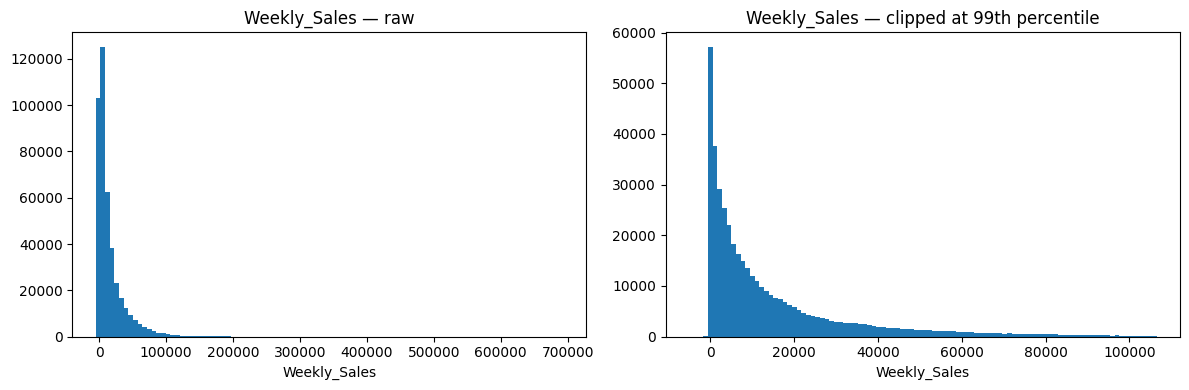

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train["Weekly_Sales"], bins=100)
axes[0].set_title("Weekly_Sales — raw")
axes[0].set_xlabel("Weekly_Sales")

clip_val = train["Weekly_Sales"].quantile(0.99)
axes[1].hist(train[train["Weekly_Sales"] < clip_val]["Weekly_Sales"], bins=100)
axes[1].set_title("Weekly_Sales — clipped at 99th percentile")
axes[1].set_xlabel("Weekly_Sales")

plt.tight_layout()
plt.show()

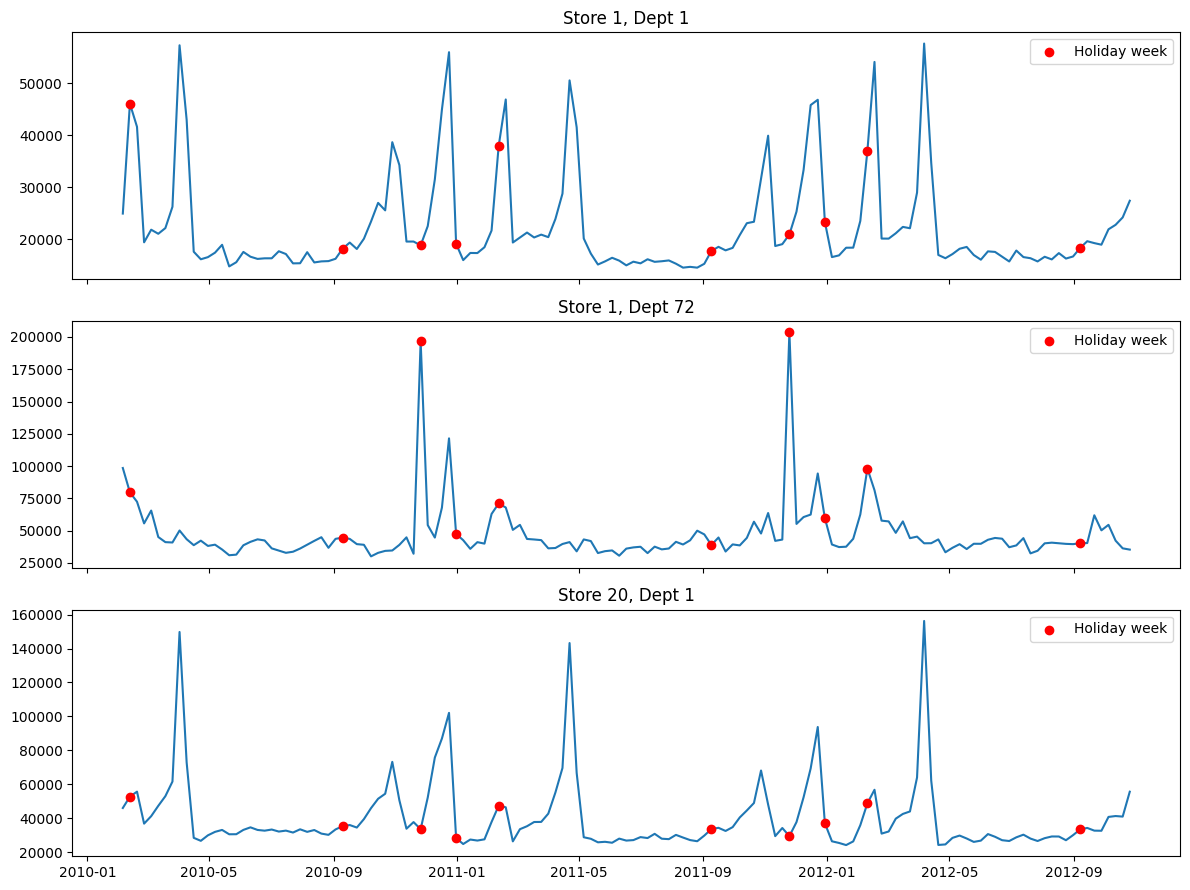

In [10]:
examples = [(1, 1), (1, 72), (20, 1)]

fig, axes = plt.subplots(len(examples), 1, figsize=(12, 3 * len(examples)), sharex=True)

for ax, (store, dept) in zip(axes, examples):
    subset = train[(train["Store"] == store) & (train["Dept"] == dept)].sort_values("Date")
    ax.plot(subset["Date"], subset["Weekly_Sales"])
    holidays = subset[subset["IsHoliday"]]
    ax.scatter(holidays["Date"], holidays["Weekly_Sales"], color="red", zorder=5, label="Holiday week")
    ax.set_title(f"Store {store}, Dept {dept}")
    ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# average weekly sales by store Type
type_summary = train_merged.groupby("Type")["Weekly_Sales"].agg(["mean", "median", "count"])
print("Sales by Store Type:")
print(type_summary)

# average store Size by Type, to see if Type is basically just a Size proxy
size_summary = stores.groupby("Type")["Size"].agg(["mean", "min", "max", "count"])
print("\nStore Size by Type:")
print(size_summary)

# holiday vs non-holiday magnitude
holiday_summary = train.groupby("IsHoliday")["Weekly_Sales"].agg(["mean", "median"])
print("\nSales — holiday vs non-holiday weeks:")
print(holiday_summary)

Sales by Store Type:
              mean    median   count
Type                                
A     20099.568043  10105.17  215478
B     12237.075977   6187.87  163495
C      9519.532538   1149.67   42597

Store Size by Type:
               mean    min     max  count
Type                                     
A     177247.727273  39690  219622     22
B     101190.705882  34875  140167     17
C      40541.666667  39690   42988      6

Sales — holiday vs non-holiday weeks:
                   mean   median
IsHoliday                       
False      15901.445069  7589.95
True       17035.823187  7947.74


In [12]:
%%writefile src/data_prep.py
import pandas as pd


def load_raw_data(data_dir="data"):
    train = pd.read_csv(f"{data_dir}/train.csv")
    test = pd.read_csv(f"{data_dir}/test.csv")
    features = pd.read_csv(f"{data_dir}/features.csv")
    stores = pd.read_csv(f"{data_dir}/stores.csv")

    train["Date"] = pd.to_datetime(train["Date"])
    test["Date"] = pd.to_datetime(test["Date"])
    features["Date"] = pd.to_datetime(features["Date"])

    return train, test, features, stores


def merge_all(sales_df, features_df, stores_df):
    df = sales_df.merge(features_df, on=["Store", "Date"], how="left", suffixes=("", "_feat"))
    df = df.merge(stores_df, on="Store", how="left")

    if "IsHoliday_feat" in df.columns:
        df = df.drop(columns=["IsHoliday_feat"])

    return df

Overwriting src/data_prep.py


In [13]:
!cat src/data_prep.py

import pandas as pd


def load_raw_data(data_dir="data"):
    train = pd.read_csv(f"{data_dir}/train.csv")
    test = pd.read_csv(f"{data_dir}/test.csv")
    features = pd.read_csv(f"{data_dir}/features.csv")
    stores = pd.read_csv(f"{data_dir}/stores.csv")

    train["Date"] = pd.to_datetime(train["Date"])
    test["Date"] = pd.to_datetime(test["Date"])
    features["Date"] = pd.to_datetime(features["Date"])

    return train, test, features, stores


def merge_all(sales_df, features_df, stores_df):
    df = sales_df.merge(features_df, on=["Store", "Date"], how="left", suffixes=("", "_feat"))
    df = df.merge(stores_df, on="Store", how="left")

    if "IsHoliday_feat" in df.columns:
        df = df.drop(columns=["IsHoliday_feat"])

    return df


In [14]:
!git add src/data_prep.py
!git config --global user.email "amama22@freeuni.edu.ge"
!git config --global user.name "amama22"
!git commit -m "Add load_raw_data and merge_all to data_prep.py"
!git push

[main bb7182b] Add load_raw_data and merge_all to data_prep.py
 1 file changed, 24 insertions(+)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 624 bytes | 624.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/amama22/walmart-forecasting
   f162219..bb7182b  main -> main


In [15]:
def add_lag_features(df, lags=[1, 2, 4, 52]):

    df = df.sort_values(["Store", "Dept", "Date"]).copy()

    for lag in lags:
        df[f"sales_lag_{lag}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(lag)

    return df

train_fe = add_lag_features(train_merged)
train_fe[["Store", "Dept", "Date", "Weekly_Sales", "sales_lag_1", "sales_lag_2", "sales_lag_52"]].head(10)

,Store,Dept,Date,Weekly_Sales,sales_lag_1,sales_lag_2,sales_lag_52
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,24924.50,NaN
3,1,1,2010-02-26,19403.54,41595.55,46039.49,NaN
4,1,1,2010-03-05,21827.90,19403.54,41595.55,NaN
5,1,1,2010-03-12,21043.39,21827.90,19403.54,NaN
6,1,1,2010-03-19,22136.64,21043.39,21827.90,NaN
7,1,1,2010-03-26,26229.21,22136.64,21043.39,NaN
8,1,1,2010-04-02,57258.43,26229.21,22136.64,NaN
9,1,1,2010-04-09,42960.91,57258.43,26229.21,NaN


In [16]:
def add_rolling_features(df, windows=[4, 8]):

    df = df.sort_values(["Store", "Dept", "Date"]).copy()

    for w in windows:
        shifted = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
        df[f"sales_rolling_mean_{w}"] = shifted.groupby([df["Store"], df["Dept"]]).transform(
            lambda s: s.rolling(window=w, min_periods=1).mean()
        )
        df[f"sales_rolling_std_{w}"] = shifted.groupby([df["Store"], df["Dept"]]).transform(
            lambda s: s.rolling(window=w, min_periods=1).std()
        )

    return df

train_fe = add_rolling_features(train_fe)
train_fe[["Store", "Dept", "Date", "Weekly_Sales", "sales_rolling_mean_4", "sales_rolling_std_4"]].head(10)

,Store,Dept,Date,Weekly_Sales,sales_rolling_mean_4,sales_rolling_std_4
0,1,1,2010-02-05,24924.50,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.500000,NaN
2,1,1,2010-02-19,41595.55,35481.995000,14930.552614
3,1,1,2010-02-26,19403.54,37519.846667,11131.900957
4,1,1,2010-03-05,21827.90,32990.770000,12832.106391
5,1,1,2010-03-12,21043.39,32216.620000,13554.047185
6,1,1,2010-03-19,22136.64,25967.595000,10467.484020
7,1,1,2010-03-26,26229.21,21102.867500,1222.784968
8,1,1,2010-04-02,57258.43,22809.285000,2325.929203
9,1,1,2010-04-09,42960.91,31666.917500,17206.391261


In [18]:
def add_holiday_proximity(df):

    df = df.copy()


    holiday_dates = pd.to_datetime([
        "2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08",   # Super Bowl
        "2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06",   # Labor Day
        "2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29",   # Thanksgiving
        "2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27",   # Christmas
    ])

    def days_to_nearest_holiday(date):
        diffs = (holiday_dates - date).days
        return diffs[abs(diffs).argmin()]  # signed: negative = holiday just passed, positive = upcoming

    df["days_to_nearest_holiday"] = df["Date"].apply(days_to_nearest_holiday)

    return df

train_fe = add_holiday_proximity(train_fe)
train_fe[["Date", "IsHoliday", "days_to_nearest_holiday"]].drop_duplicates().head(20)

,Date,IsHoliday,days_to_nearest_holiday
0,2010-02-05,False,7
1,2010-02-12,True,0
2,2010-02-19,False,-7
3,2010-02-26,False,-14
4,2010-03-05,False,-21
5,2010-03-12,False,-28
6,2010-03-19,False,-35
7,2010-03-26,False,-42
8,2010-04-02,False,-49
9,2010-04-09,False,-56


In [19]:
def add_expanding_dept_avg(df):

    df = df.copy()

    # step 1: collapse across stores -> one row per (Dept, Date)
    dept_weekly = df.groupby(["Dept", "Date"])["Weekly_Sales"].mean().reset_index()
    dept_weekly = dept_weekly.sort_values(["Dept", "Date"])

    # step 2: expanding average, shifted so "today" is excluded from its own average
    dept_weekly["dept_avg_sales_expanding"] = (
        dept_weekly.groupby("Dept")["Weekly_Sales"]
        .apply(lambda s: s.shift(1).expanding().mean())
        .reset_index(level=0, drop=True)
    )

    # step 3: broadcast back onto original rows
    df = df.merge(
        dept_weekly[["Dept", "Date", "dept_avg_sales_expanding"]],
        on=["Dept", "Date"], how="left"
    )
    return df

train_fe = add_expanding_dept_avg(train_fe)
train_fe[["Store", "Dept", "Date", "Weekly_Sales", "dept_avg_sales_expanding"]].head(15)

,Store,Dept,Date,Weekly_Sales,dept_avg_sales_expanding
0,1,1,2010-02-05,24924.50,NaN
1,1,1,2010-02-12,46039.49,19596.298000
2,1,1,2010-02-19,41595.55,25989.064556
3,1,1,2010-02-26,19403.54,25609.430889
4,1,1,2010-03-05,21827.90,22992.581944
5,1,1,2010-03-12,21043.39,21783.632533
6,1,1,2010-03-19,22136.64,21130.386111
7,1,1,2010-03-26,26229.21,20799.653079
8,1,1,2010-04-02,57258.43,21104.486500
9,1,1,2010-04-09,42960.91,24813.747358


In [20]:
train_fe.shape

(421570, 26)

In [21]:
def add_expanding_store_avg(df):

    df = df.copy()

    # step 1: collapse across depts -> one row per (Store, Date)
    store_weekly = df.groupby(["Store", "Date"])["Weekly_Sales"].mean().reset_index()
    store_weekly = store_weekly.sort_values(["Store", "Date"])

    # step 2: expanding average, shifted so "today" is excluded from its own average
    store_weekly["store_avg_sales_expanding"] = (
        store_weekly.groupby("Store")["Weekly_Sales"]
        .apply(lambda s: s.shift(1).expanding().mean())
        .reset_index(level=0, drop=True)
    )

    # step 3: broadcast back onto original rows
    df = df.merge(
        store_weekly[["Store", "Date", "store_avg_sales_expanding"]],
        on=["Store", "Date"], how="left"
    )
    return df

train_fe = add_expanding_store_avg(train_fe)
train_fe[["Store", "Dept", "Date", "Weekly_Sales", "store_avg_sales_expanding"]].head(15)

,Store,Dept,Date,Weekly_Sales,store_avg_sales_expanding
0,1,1,2010-02-05,24924.50,NaN
1,1,1,2010-02-12,46039.49,22516.313699
2,1,1,2010-02-19,41595.55,22660.639072
3,1,1,2010-02-26,19403.54,22467.677965
4,1,1,2010-03-05,21827.90,21745.645939
5,1,1,2010-03-12,21043.39,21656.261080
6,1,1,2010-03-19,22136.64,21333.508868
7,1,1,2010-03-26,26229.21,21207.523058
8,1,1,2010-04-02,57258.43,20994.829064
9,1,1,2010-04-09,42960.91,21123.441082


In [22]:
train_fe.shape

(421570, 27)

In [23]:
%%writefile src/feature_engineering.py
import pandas as pd


def add_lag_features(df, lags=[1, 2, 4, 52]):

    df = df.sort_values(["Store", "Dept", "Date"]).copy()

    for lag in lags:
        df[f"sales_lag_{lag}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(lag)

    return df


def add_rolling_features(df, windows=[4, 8]):

    df = df.sort_values(["Store", "Dept", "Date"]).copy()

    for w in windows:
        shifted = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
        df[f"sales_rolling_mean_{w}"] = shifted.groupby([df["Store"], df["Dept"]]).transform(
            lambda s: s.rolling(window=w, min_periods=1).mean()
        )
        df[f"sales_rolling_std_{w}"] = shifted.groupby([df["Store"], df["Dept"]]).transform(
            lambda s: s.rolling(window=w, min_periods=1).std()
        )

    return df


def add_holiday_proximity(df):

    df = df.copy()

    holiday_dates = pd.to_datetime([
        "2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08",   # Super Bowl
        "2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06",   # Labor Day
        "2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29",   # Thanksgiving
        "2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27",   # Christmas
    ])

    def days_to_nearest_holiday(date):
        diffs = (holiday_dates - date).days
        return diffs[abs(diffs).argmin()]

    df["days_to_nearest_holiday"] = df["Date"].apply(days_to_nearest_holiday)
    return df


def add_expanding_dept_avg(df):

    df = df.copy()

    dept_weekly = df.groupby(["Dept", "Date"])["Weekly_Sales"].mean().reset_index()
    dept_weekly = dept_weekly.sort_values(["Dept", "Date"])

    dept_weekly["dept_avg_sales_expanding"] = (
        dept_weekly.groupby("Dept")["Weekly_Sales"]
        .apply(lambda s: s.shift(1).expanding().mean())
        .reset_index(level=0, drop=True)
    )

    df = df.merge(
        dept_weekly[["Dept", "Date", "dept_avg_sales_expanding"]],
        on=["Dept", "Date"], how="left"
    )
    return df


def add_expanding_store_avg(df):

    df = df.copy()

    store_weekly = df.groupby(["Store", "Date"])["Weekly_Sales"].mean().reset_index()
    store_weekly = store_weekly.sort_values(["Store", "Date"])

    store_weekly["store_avg_sales_expanding"] = (
        store_weekly.groupby("Store")["Weekly_Sales"]
        .apply(lambda s: s.shift(1).expanding().mean())
        .reset_index(level=0, drop=True)
    )

    df = df.merge(
        store_weekly[["Store", "Date", "store_avg_sales_expanding"]],
        on=["Store", "Date"], how="left"
    )
    return df


def build_all_features(df):
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_holiday_proximity(df)
    df = add_expanding_dept_avg(df)
    df = add_expanding_store_avg(df)
    return df

Overwriting src/feature_engineering.py


In [24]:
!git add src/feature_engineering.py
!git commit -m "Add features"
!git push

[main dcf36da] Add features
 1 file changed, 95 insertions(+)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.07 KiB | 1.07 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/amama22/walmart-forecasting
   bb7182b..dcf36da  main -> main


In [25]:
import numpy as np

def wmae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    is_holiday = np.asarray(is_holiday)

    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

test_wmae = wmae(y_true=[100, 200, 50], y_pred=[90, 210, 60], is_holiday=[True, False, False])
print("test WMAE:", test_wmae)

test WMAE: 10.0


In [26]:
test_wmae_2 = wmae(y_true=[100, 200, 50], y_pred=[80, 200, 50], is_holiday=[True, False, False])
print("holiday row wrong:", test_wmae_2)

test_wmae_3 = wmae(y_true=[100, 200, 50], y_pred=[100, 200, 30], is_holiday=[True, False, False])
print("non-holiday row wrong:", test_wmae_3)

holiday row wrong: 14.285714285714286
non-holiday row wrong: 2.857142857142857


In [27]:
import pandas as pd
import numpy as np

def walk_forward_splits(df, date_col="Date", n_splits=3, horizon_weeks=38):
    dates = pd.to_datetime(df[date_col])
    unique_dates = np.sort(dates.unique())

    horizon_days = horizon_weeks * 7
    splits = []
    last_date = unique_dates[-1]

    for i in range(n_splits):
        val_end = last_date - pd.Timedelta(days=horizon_days * i)
        val_start = val_end - pd.Timedelta(days=horizon_days)

        train_mask = dates < val_start
        val_mask = (dates >= val_start) & (dates <= val_end)

        if train_mask.sum() == 0:
            continue

        splits.append((train_mask.values, val_mask.values))

    return list(reversed(splits))

splits = walk_forward_splits(train_merged, n_splits=3)

for i, (train_mask, val_mask) in enumerate(splits):
    train_dates = train_merged.loc[train_mask, "Date"]
    val_dates = train_merged.loc[val_mask, "Date"]
    print(f"split {i}:")
    print(f"  train: {train_dates.min()} to {train_dates.max()}  ({train_mask.sum()} rows)")
    print(f"  val:   {val_dates.min()} to {val_dates.max()}  ({val_mask.sum()} rows)")
    print()

split 0:
  train: 2010-02-05 00:00:00 to 2010-08-13 00:00:00  (82022 rows)
  val:   2010-08-20 00:00:00 to 2011-05-13 00:00:00  (114593 rows)

split 1:
  train: 2010-02-05 00:00:00 to 2011-05-06 00:00:00  (193648 rows)
  val:   2011-05-13 00:00:00 to 2012-02-03 00:00:00  (115311 rows)

split 2:
  train: 2010-02-05 00:00:00 to 2012-01-27 00:00:00  (305982 rows)
  val:   2012-02-03 00:00:00 to 2012-10-26 00:00:00  (115588 rows)



In [28]:
%%writefile src/evaluation.py
import numpy as np
import pandas as pd


def wmae(y_true, y_pred, is_holiday):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    is_holiday = np.asarray(is_holiday)

    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def walk_forward_splits(df, date_col="Date", n_splits=3, horizon_weeks=38):

    dates = pd.to_datetime(df[date_col])
    unique_dates = np.sort(dates.unique())

    horizon_days = horizon_weeks * 7
    splits = []
    last_date = unique_dates[-1]

    for i in range(n_splits):
        val_end = last_date - pd.Timedelta(days=horizon_days * i)
        val_start = val_end - pd.Timedelta(days=horizon_days)

        train_mask = dates < val_start
        val_mask = (dates >= val_start) & (dates <= val_end)

        if train_mask.sum() == 0:
            continue

        splits.append((train_mask.values, val_mask.values))

    return list(reversed(splits))

Overwriting src/evaluation.py


In [29]:
!git add src/evaluation.py
!git commit -m "Add wmae and walk_forward_splits functions"
!git push

[main a41665f] Add wmae and walk_forward_splits functions
 1 file changed, 36 insertions(+)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 755 bytes | 755.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/amama22/walmart-forecasting
   dcf36da..a41665f  main -> main
